# Elements and Solvers

Three element types and three solvers, on a cantilever beam.

In [1]:
import contextlib
import io

import matplotlib.pyplot as plt

from fem2d.meshers import Mesh, Q8Mesh
from fem2d.postprocessing import Plotting
from fem2d.solvers import FEMSolvers

# The nonlinear solvers print their iteration history; silence it for the sweeps.
quiet = lambda: contextlib.redirect_stdout(io.StringIO())

## Problem

A cantilever pinned at the left edge with a downward point load at the tip.
`plane` odd is plane strain, even is plane stress.

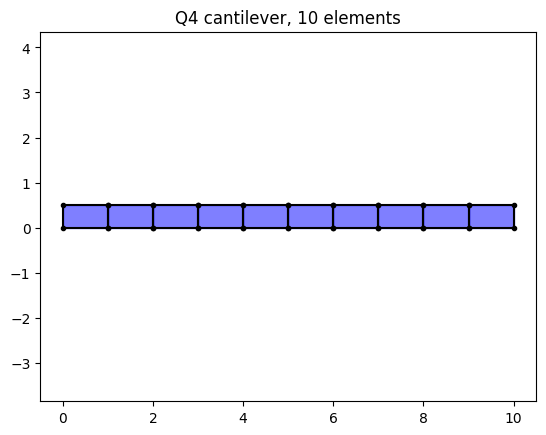

In [2]:
E, v, t, plane = 210000.0, 0.3, 1.0, 1
el_num, Length, Height, Load = 10, 10.0, 0.5, -25.0


def cantilever(ElementType, Length=Length, Height=Height):
    """Q4 and 5B come from Mesh, Q8 needs the eight node mesher."""
    Mesher = Q8Mesh if ElementType == 'Q8' else Mesh
    m = Mesher(E, v, t, plane, ElementType)
    m.SimpleBeam(el_num, Length, Height, Load)
    return m


ax = Plotting.InitialMesh(cantilever('Q4'))
ax.set_title('Q4 cantilever, 10 elements');

## Elements

- **Q4** four node quadrilateral
- **5B** five parameter assumed stress (Pian-Sumihara)
- **Q8** eight node quadrilateral

Linear tip deflection against beam theory. Q4 shear locks badly at this aspect
ratio; the other two do not.

In [3]:
I = t*Height**3/12
EulerBernoulli = Load*Length**3/(3*(E/(1 - v**2))*I)   # plane strain modulus, no shear

print(f"{'element':<10}{'tip uy':>12}{'/ beam theory':>16}")
for ElementType in ('Q4', '5B', 'Q8'):
    m = cantilever(ElementType)
    FEMSolvers.LinearSolver(m)
    print(f"{ElementType:<10}{m.U[-1, 0]:>12.5f}{m.U[-1, 0]/EulerBernoulli:>16.3f}")

print(f"\nEuler-Bernoulli reference: {EulerBernoulli:.5f}")

element         tip uy   / beam theory
Q4            -1.32361           0.382
5B            -3.46428           0.999
Q8            -3.46926           1.001

Euler-Bernoulli reference: -3.46667


## Solvers

- **Linear** one solve, small deformation
- **NonLinear** Newton with the load applied in steps
- **ArcLength** continuation, traces equilibrium paths past limit points

Each prints its convergence history:

In [4]:
m = cantilever('5B')
FEMSolvers.NonLinearSolver(m, LoadSteps=2, tol=1e-6)

---------------
Load Step 1
---------------
Interation 0, Residual Norm 1.0
Interation 1, Residual Norm 3107.243047500301
Interation 2, Residual Norm 118.27009195370194
Interation 3, Residual Norm 0.24928962820616046
Interation 4, Residual Norm 0.08729702239850276
Interation 5, Residual Norm 1.6961816501655623e-05


Interation 6, Residual Norm 4.191217170008949e-10
---------------
Load Step 2
---------------
Interation 0, Residual Norm 1.0


Interation 1, Residual Norm 2808.7411248802505
Interation 2, Residual Norm 97.9453446529704
Interation 3, Residual Norm 0.49137881793540555
Interation 4, Residual Norm 5.014090506176176
Interation 5, Residual Norm 0.0021891649538795716
Interation 6, Residual Norm 0.00011076329686477645
Interation 7, Residual Norm 1.4097093585434583e-11


### All nine combinations

The arc length solver stops at a fixed accumulated arc length rather than a
fixed load, so each element reaches a different load factor: the artificially
stiff Q4 travels much further in load for the same arc length.

In [5]:
Solvers = {
    'Linear':    lambda m: FEMSolvers.LinearSolver(m),
    'NonLinear': lambda m: FEMSolvers.NonLinearSolver(m, LoadSteps=3, tol=1e-6),
    'ArcLength': lambda m: FEMSolvers.ArcLengthSolver(m, ArcLength=1.0, TotalArcLength=3.0, tol=1e-7),
}

Results = {}
print(f"{'element':<9}{'solver':<12}{'tip uy':>11}{'load factor':>13}{'steps':>7}")
for ElementType in ('Q4', '5B', 'Q8'):
    for name, run in Solvers.items():
        m = cantilever(ElementType)
        with quiet():
            run(m)
        Results[ElementType, name] = m
        LoadFactor = 1.0 if name == 'Linear' else m.LoadValues[-1]
        Steps = '-' if name == 'Linear' else str(m.AllU.shape[1] - 1)
        print(f"{ElementType:<9}{name:<12}{m.U[-1, 0]:>11.5f}{LoadFactor:>13.4f}{Steps:>7}")

element  solver           tip uy  load factor  steps


Q4       Linear         -1.32361       1.0000      -


Q4       NonLinear      -1.31473       1.0000      3


Q4       ArcLength      -1.24749       0.9477      3
5B       Linear         -3.46428       1.0000      -


5B       NonLinear      -3.18954       1.0000      3


5B       ArcLength      -1.24797       0.3623      3
Q8       Linear         -3.46926       1.0000      -


Q8       NonLinear      -3.19380       1.0000      3


Q8       ArcLength      -0.82126       0.2367      3


## Deformed shapes

`Overlay` draws the undeformed mesh under the deformed one; `steps` fades in the
intermediate load steps.

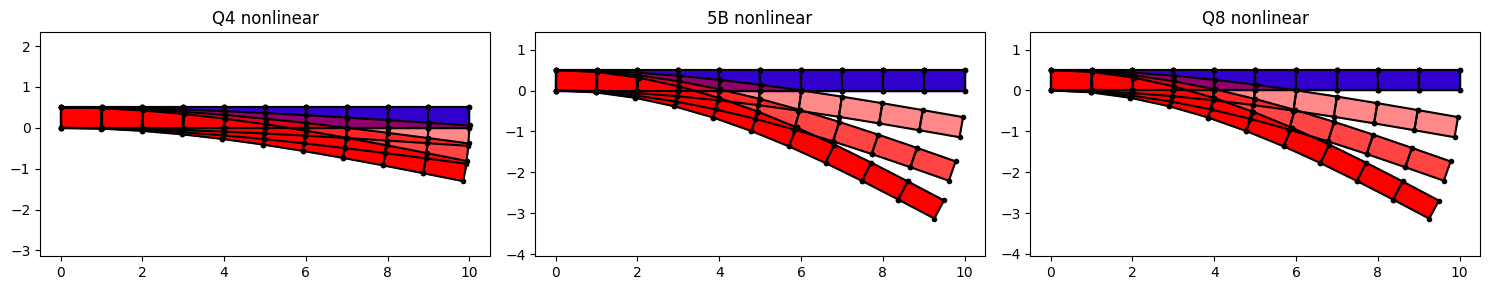

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.0))
for ax, ElementType in zip(axes, ('Q4', '5B', 'Q8')):
    Plotting.Overlay(Results[ElementType, 'NonLinear'], ax=ax, steps=1)
    ax.set_title(f"{ElementType} nonlinear")
plt.tight_layout()

## Load paths

`LoadPath` plots the load factor against the displacement of the loaded node.

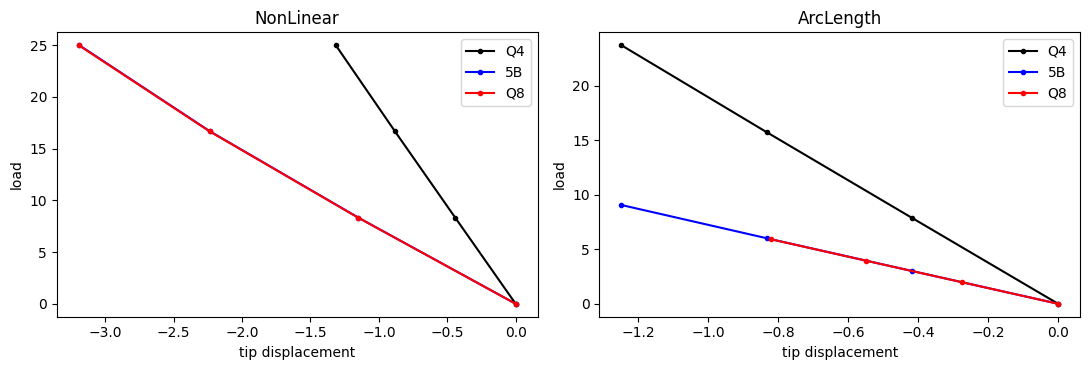

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for ax, Solver in zip(axes, ('NonLinear', 'ArcLength')):
    for ElementType, colour in zip(('Q4', '5B', 'Q8'), ('k', 'b', 'r')):
        Plotting.LoadPath(Results[ElementType, Solver], ax=ax, c=colour)
    ax.set(xlabel='tip displacement', ylabel='load', title=Solver)
    ax.legend(['Q4', '5B', 'Q8'])
plt.tight_layout()

## Meshers

`SimpleBeam`, `SingleElement`, `LeeFrame` and `SemiCircularArch`. The eight node
`Q8Mesh` provides `SimpleBeam` and `SingleElement` only; its `SemiCircularArch`
raises `NotImplementedError`.

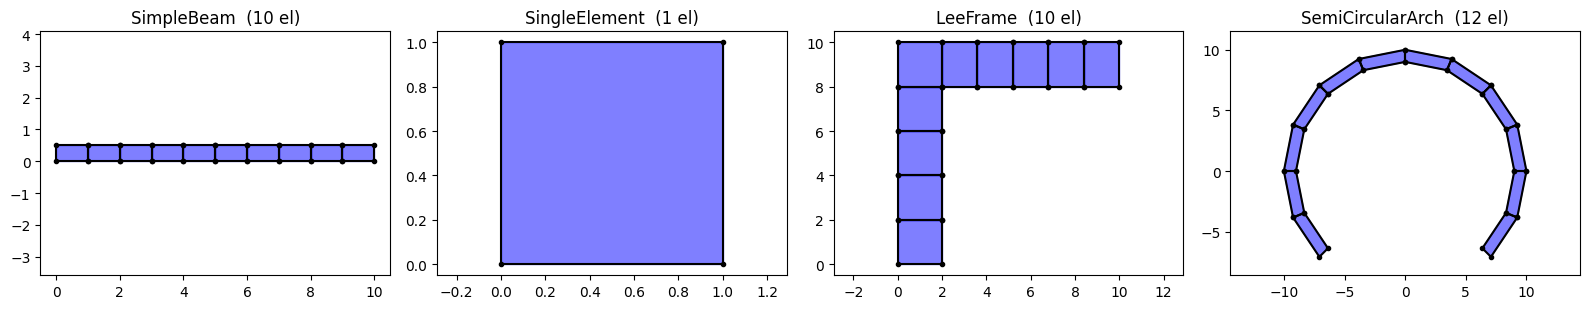

In [8]:
Meshers = {
    'SimpleBeam':       lambda m: m.SimpleBeam(10, 10.0, 0.5, Load),
    'SingleElement':    lambda m: m.SingleElement(1.0, 1.0, Load),
    'LeeFrame':         lambda m: m.LeeFrame(10, [10.0, 10.0], Load),
    'SemiCircularArch': lambda m: m.SemiCircularArch(12, 10.0, [10.0, 10.0], 1.0, Load),
}

fig, axes = plt.subplots(1, 4, figsize=(16, 3.2))
for ax, (name, build) in zip(axes, Meshers.items()):
    m = Mesh(E, v, t, plane, 'Q4')
    build(m)
    Plotting.InitialMesh(m, ax=ax)
    ax.set_title(f"{name}  ({m.Elements.shape[0]} el)")
plt.tight_layout()